# Cherry Blossom Phenology — Process-Based Models

Loads the GMU yedoensis (*Cerasus yedoensis*, Somei-yoshino) and sargentii
(*C. sargentii*) cherry datasets for Japan, explores them visually, fits all
available process-based models on a temporal train/test split
(train: 1986–2009, test: 2010–present), evaluates and compares the results,
and finally visualises how each model's chill and forcing responses differ on
a single representative sample per species.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pysephone.constants import KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.gdd import GDDModel
from pysephone.models.cf import (
    UtahGDDModel,
    ChillingDaysGDDModel,
    DynamicGDDModel,
)
from pysephone.models.util.func_phenology import (
    func_utah_chill,
    func_chilling_days,
    func_dynamic_chill_daily,
)
from pysephone.visualize.dataset import (
    observation_doy_histograms,
    observation_doy_over_time,
    observation_map,
    observation_mean_trend,
)

## 1. Load data

Both species are observed as first bloom (observation key `gmu_0`).  
A season starting 1 October (before winter chilling) and running for 365 days
captures the full chill–force cycle.

`GMU_Cherry_Japan_YS` contains both yedoensis (species_id 0) and sargentii
(species_id 1) and shares aggregated location IDs with the full Japan dataset,
so no redundant downloading occurs when the Japan data is already cached.

In [ ]:
from pysephone.dataset.util.feature_cache import FeatureCache

DATA_KEYS = ['temperature_2m_mean']

OBS_KEY      = 'gmu_0'
CUTOFF       = 2010
OPT_MAX_TIME = 60.0  # seconds per optimisation phase per model

SPECIES_YEDOENSIS = ('GMU_cherry', 0)
SPECIES_SARGENTII = ('GMU_cherry', 1)

cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('GMU_Cherry_Japan_YS', DATA_KEYS))
ds_ys  = Dataset.load('GMU_Cherry_Japan_YS', calendar=cal, feature_providers=[_cache])

ds_y = ds_ys.select_species([SPECIES_YEDOENSIS])
ds_s = ds_ys.select_species([SPECIES_SARGENTII])

for name, ds in [('Yedoensis', ds_y), ('Sargentii', ds_s)]:
    print(f"{name}: {len(ds)} samples | "
          f"years {min(ds.years)}–{max(ds.years)} | "
          f"locations {len(ds.locations)}")


## 2. Explore the datasets

### 2a. Yedoensis (*C. yedoensis* — Somei-yoshino)

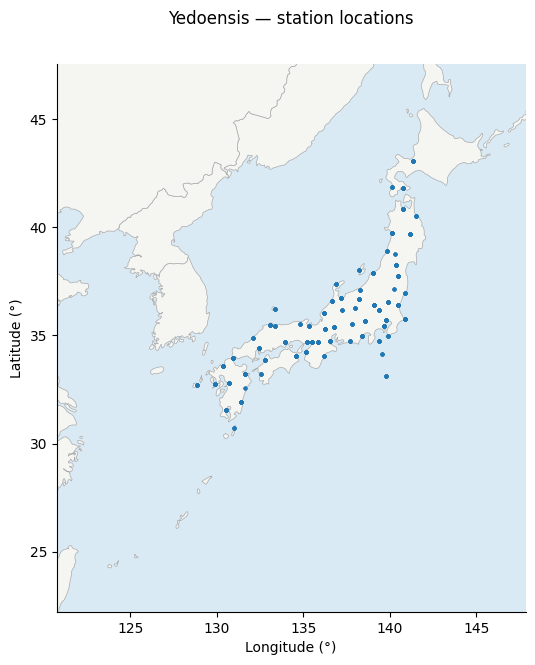

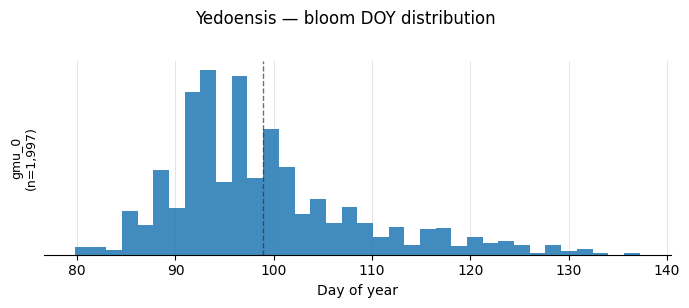

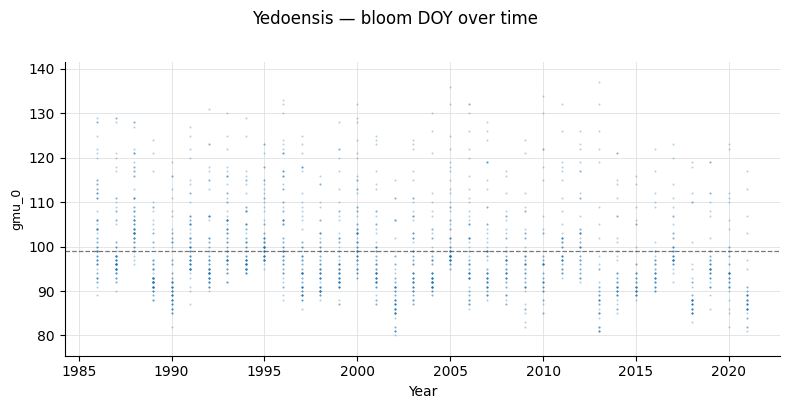

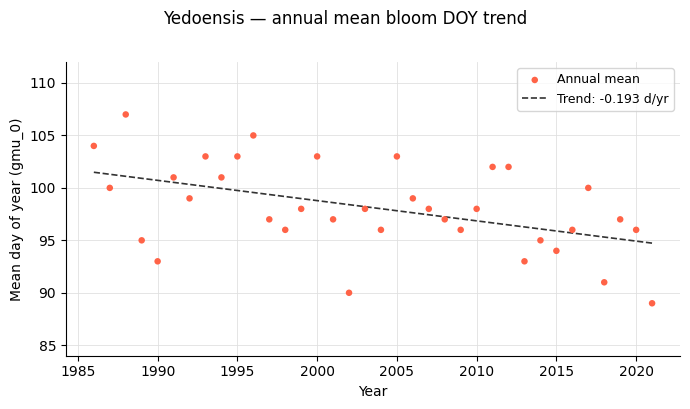

In [5]:
obs_y = ds_y.observations

fig = observation_map(obs_y)
fig.suptitle('Yedoensis — station locations', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs_y)
fig.suptitle('Yedoensis — bloom DOY distribution', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_over_time(obs_y)
fig.suptitle('Yedoensis — bloom DOY over time', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_mean_trend(obs_y, OBS_KEY)
fig.suptitle('Yedoensis — annual mean bloom DOY trend', y=1.01)
plt.tight_layout()
plt.show()

### 2b. Sargentii (*C. sargentii*)

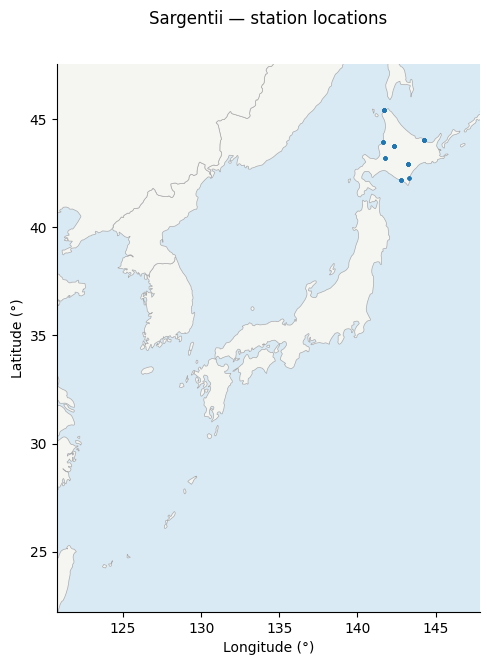

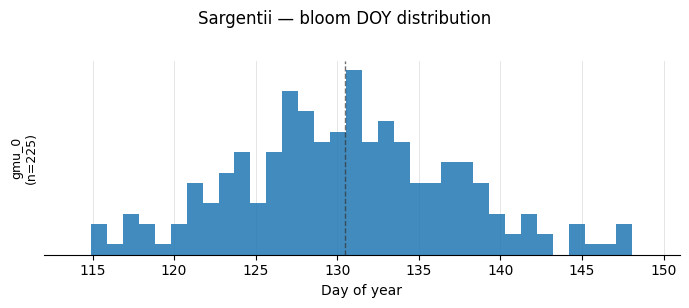

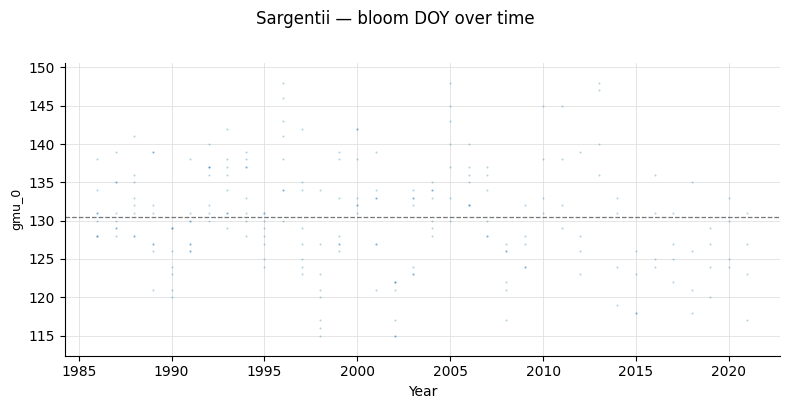

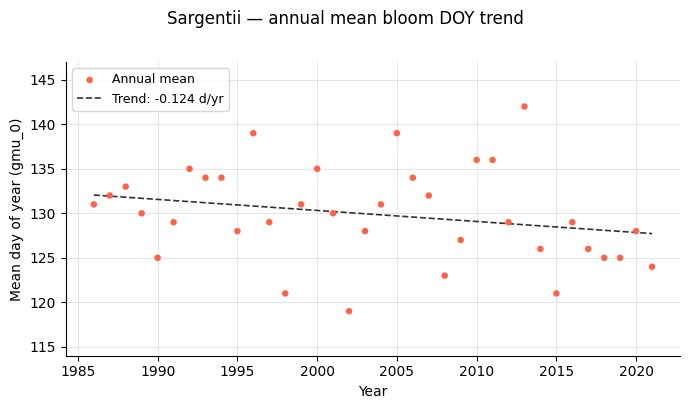

In [6]:
obs_s = ds_s.observations

fig = observation_map(obs_s)
fig.suptitle('Sargentii — station locations', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs_s)
fig.suptitle('Sargentii — bloom DOY distribution', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_over_time(obs_s)
fig.suptitle('Sargentii — bloom DOY over time', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_mean_trend(obs_s, OBS_KEY)
fig.suptitle('Sargentii — annual mean bloom DOY trend', y=1.01)
plt.tight_layout()
plt.show()

## 3. Train / test split

Temporal cutoff: **train 1986–2009**, **test 2010–present**.

In [7]:
def temporal_split(ds, cutoff):
    years = sorted(ds.years)
    trn = [y for y in years if y < cutoff]
    tst = [y for y in years if y >= cutoff]
    return ds.select_years(trn), ds.select_years(tst)

ds_y_trn, ds_y_tst = temporal_split(ds_y, CUTOFF)
ds_s_trn, ds_s_tst = temporal_split(ds_s, CUTOFF)

for species, trn, tst in [
    ('Yedoensis', ds_y_trn, ds_y_tst),
    ('Sargentii', ds_s_trn, ds_s_tst),
]:
    print(f"{species}: train {len(trn)}, test {len(tst)}")

Yedoensis: train 1513, test 484
Sargentii: train 177, test 48


## 4. Fit process-based models

Four models are fitted on each species independently:

| Model | Chilling | Forcing |
|---|---|---|
| `GDDModel` | — | GDU from season start |
| `UtahGDDModel` | Utah chill units | GDU after chill gate |
| `ChillingDaysGDDModel` | Days ≤ *t_chill* | GDU after chill gate |
| `DynamicGDDModel` | Dynamic (chill portions) | GDU after chill gate |

In [8]:
target_fn = lambda s: s['observations'][OBS_KEY]

OPT_KW = dict(opt_max_time=OPT_MAX_TIME)

MODEL_SPECS = [
    (
        'GDD',
        GDDModel,
        dict(threshold=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'Utah+GDD',
        UtahGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'ChillingDays+GDD',
        ChillingDaysGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, **OPT_KW),
    ),
    (
        'Dynamic+GDD',
        DynamicGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
]

fitted = {}  # {species: {model_name: model}}

for species, ds_trn in [('yedoensis', ds_y_trn), ('sargentii', ds_s_trn)]:
    fitted[species] = {}
    for name, cls, kwargs in MODEL_SPECS:
        print(f"Fitting {name} on {species}...", end=' ', flush=True)
        model, _ = cls.fit(
            target_fn=target_fn,
            dataset=ds_trn,
            model_kwargs=kwargs,
        )
        fitted[species][name] = model
        print('done')
        print(f"  params: {model.params}")

Fitting GDD on yedoensis... done
  params: {'threshold': 1921.8892897344283, 't_base': 0.0}
Fitting Utah+GDD on yedoensis... done
  params: {'th_c': 2.8267904613404937, 'th_f': 433.1134097464484, 't_base': 2.687931902055608}
Fitting ChillingDays+GDD on yedoensis... done
  params: {'th_c': 35.613907710369624, 'th_f': 550.5826207880842, 't_chill': 13.030598934316016, 't_base': 1.6387866757216323}
Fitting Dynamic+GDD on yedoensis... done
  params: {'th_c': 16.853843552159013, 'th_f': 256.71717093128024, 't_base': 4.8430462292934555, 'amplitude': 7.467447261107205}
Fitting GDD on sargentii... done
  params: {'threshold': 663.9046144622151, 't_base': 1.6042283855679849}
Fitting Utah+GDD on sargentii... done
  params: {'th_c': 50.14706584437906, 'th_f': 111.22173830331752, 't_base': 3.9005205919120804}
Fitting ChillingDays+GDD on sargentii... done
  params: {'th_c': 11.083709721573472, 'th_f': 333.1371302696466, 't_chill': 7.683178145444828, 't_base': 0.5613331151075107}
Fitting Dynamic+GDD 

## 5. Evaluate

In [9]:
results = {}  # {species: {model_name: result}}

for species, ds_trn, ds_tst in [
    ('yedoensis', ds_y_trn, ds_y_tst),
    ('sargentii', ds_s_trn, ds_s_tst),
]:
    results[species] = {}
    for name, model in fitted[species].items():
        results[species][name] = SingleTargetRegression.run(
            model=model,
            dataset_train=ds_trn,
            dataset_test=ds_tst,
            target_fn=target_fn,
            run_name=f'{name.lower().replace("+", "_")}_{species}',
        )

### 5a. Metrics summary

In [10]:
rows = []
for species in ('yedoensis', 'sargentii'):
    for model_name, result in results[species].items():
        m = result.compute_metrics()
        for split in ('train', 'test'):
            rows.append({
                'Species':  species.capitalize(),
                'Model':    model_name,
                'Split':    split,
                'N':        m[split]['n'],
                'RMSE':     round(m[split]['rmse'], 2),
                'MAE':      round(m[split]['mae'], 2),
                'Bias':     round(m[split]['bias'], 2),
                'R²':       round(m[split]['r2'], 3),
            })

df_metrics = pd.DataFrame(rows).set_index(['Species', 'Model', 'Split'])
df_metrics

N   RMSE    MAE  Bias      R²
Species   Model            Split                                  
Yedoensis GDD              train  1513  36.16  28.87  6.82 -13.438
                           test    484  31.83  25.74  6.25  -9.248
          Utah+GDD         train  1513  38.06  15.19  8.30 -14.992
                           test    484  28.25  11.37  5.82  -7.074
          ChillingDays+GDD train  1513  15.23  12.67  0.97  -1.561
                           test    484  14.54  11.87  1.35  -1.138
          Dynamic+GDD      train  1513  18.93  14.84 -2.48  -2.956
                           test    484  17.12  14.01 -2.93  -1.963
Sargentii GDD              train   177  12.41   9.61  3.35  -2.584
                           test     48  11.67   9.38  9.08  -1.263
          Utah+GDD         train   177   6.10   4.39  0.15   0.133
                           test     48   6.24   4.42  3.17   0.353
          ChillingDays+GDD train   177   6.71   5.12 -0.32  -0.047
                           test     48   7.52   5.90  3.23   0.060
          Dynamic+GDD      train   177   6.92   5.17 -0.03  -0.115
                           test     48   6.64   4.85  3.31   0.267

### 5b. Evaluation plots — Yedoensis

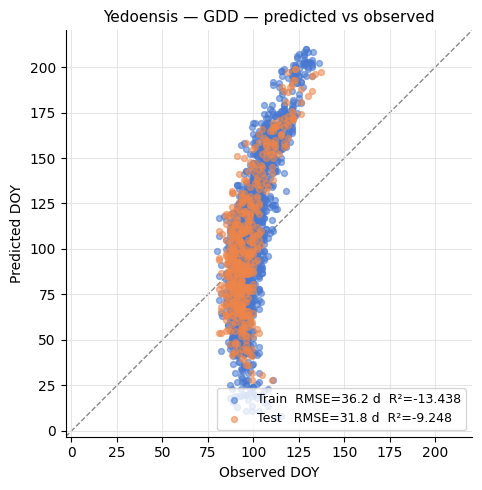

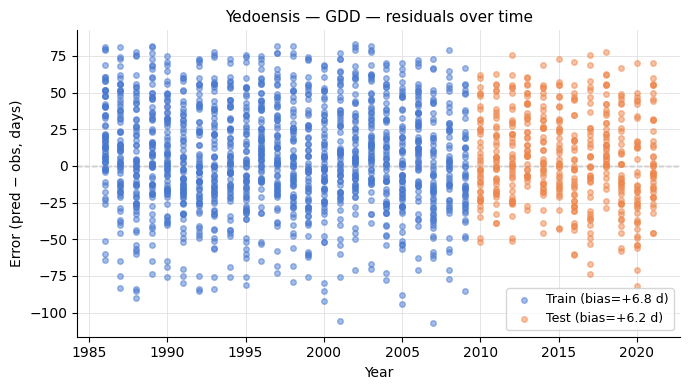

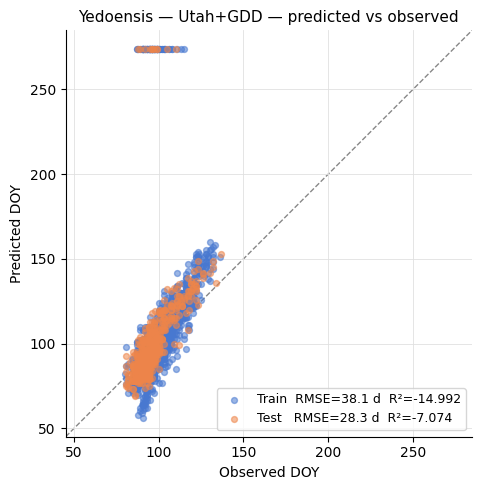

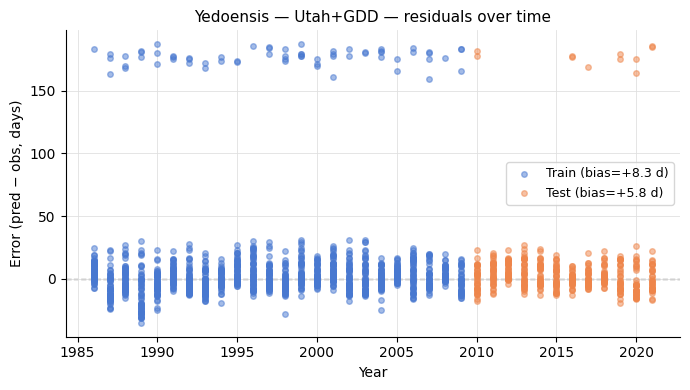

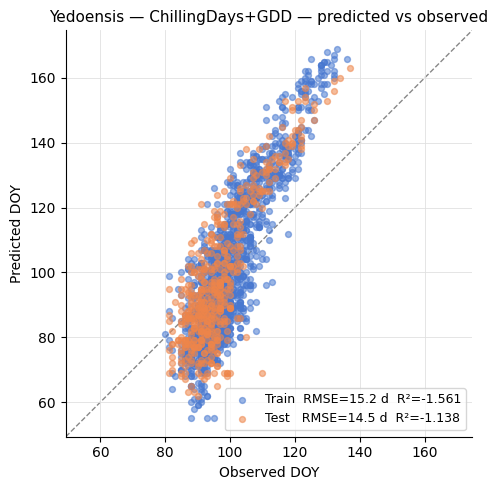

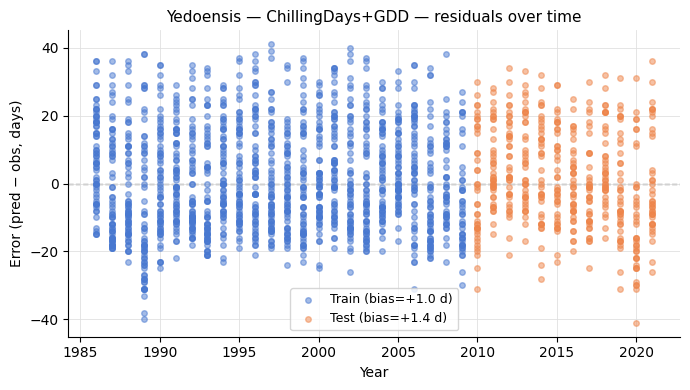

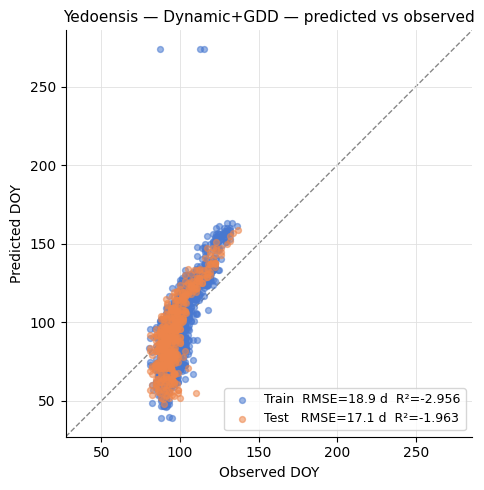

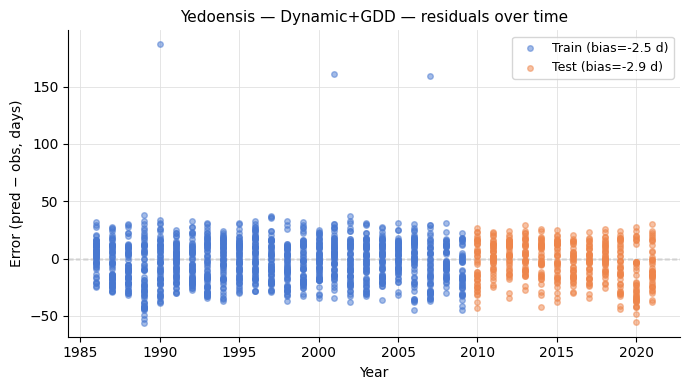

In [11]:
for name, result in results['yedoensis'].items():
    fig = result.plot_scatter(title=f'Yedoensis — {name} — predicted vs observed')
    plt.tight_layout()
    plt.show()

    fig = result.plot_residuals_over_time(title=f'Yedoensis — {name} — residuals over time')
    plt.tight_layout()
    plt.show()

### 5c. Evaluation plots — Sargentii

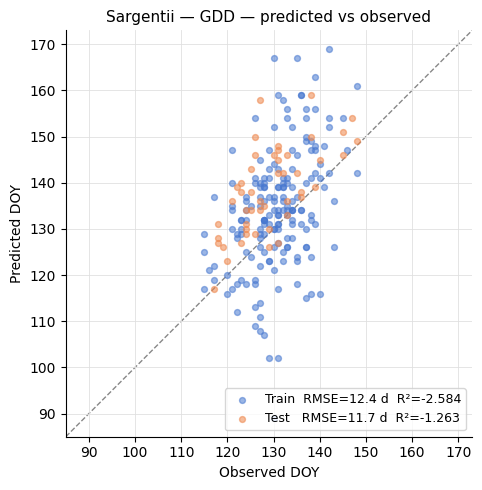

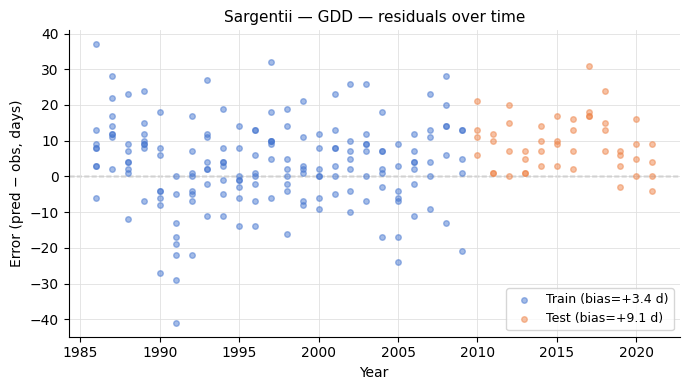

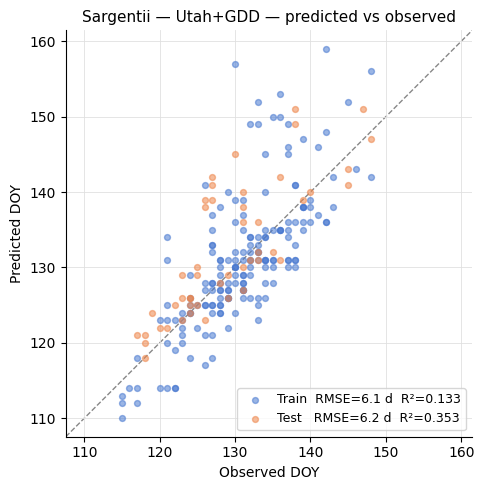

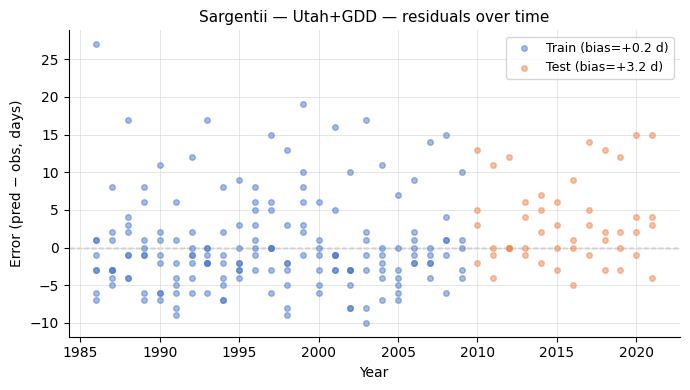

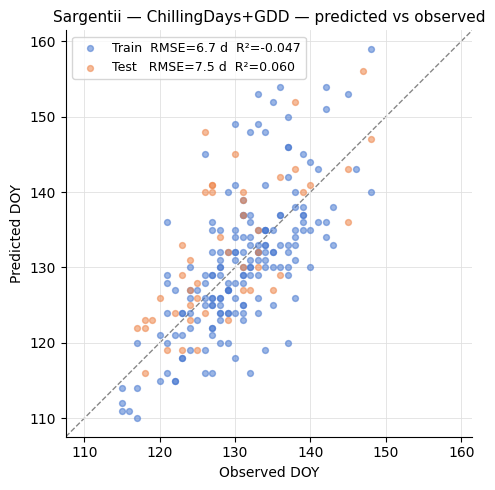

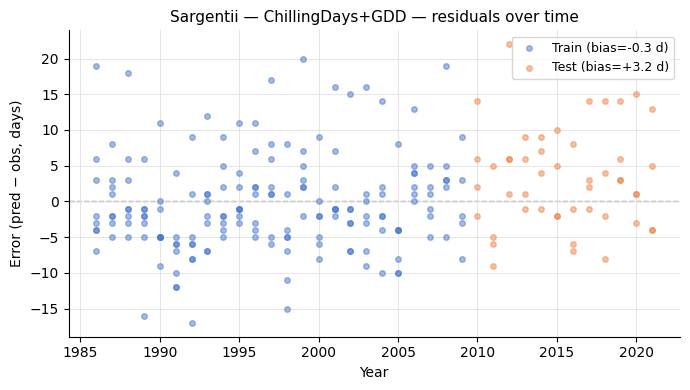

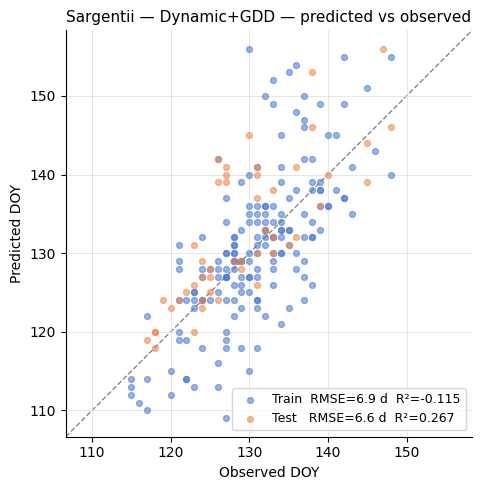

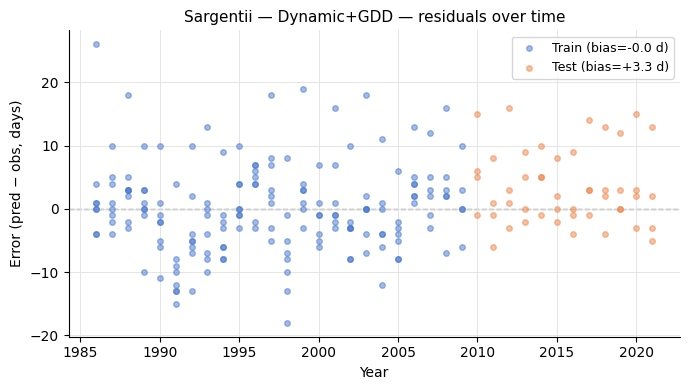

In [12]:
for name, result in results['sargentii'].items():
    fig = result.plot_scatter(title=f'Sargentii — {name} — predicted vs observed')
    plt.tight_layout()
    plt.show()

    fig = result.plot_residuals_over_time(title=f'Sargentii — {name} — residuals over time')
    plt.tight_layout()
    plt.show()

## 6. Model response comparison on a single sample

We pick a representative sample from each species and visualise:

- **Top**: daily mean temperature over the season
- **Middle**: cumulative chill units per model (CF models only), with the fitted chilling threshold
- **Bottom**: cumulative forcing (GDU) per model — gated by chilling for CF models,
  ungated from season start for `GDDModel` — with the fitted forcing threshold and
  a vertical marker at the predicted bloom day

In [13]:
def pick_sample(ds, year=None):
    """Return the first sample for *year* (or the earliest available year)."""
    if year is None:
        year = min(ds.years)
    for item in ds.iter_items():
        if item['year'] == year:
            return item
    raise ValueError(f"No sample found for year {year}")


def compute_model_response(model, sample):
    """Return arrays needed for the response plot."""
    ts = sample[KEY_FEATURES]['temperature_2m_mean']

    if isinstance(model, (UtahGDDModel, ChillingDaysGDDModel, DynamicGDDModel)):
        cs, fs = model.get_cf_features(sample)
        chill_cs = np.cumsum(cs)
        chill_gate = (chill_cs >= model.threshold_c).astype(float)
        force_cs = np.cumsum(fs * chill_gate)
        th_c = model.threshold_c
        th_f = model.threshold_f
    elif isinstance(model, GDDModel):
        chill_cs = None
        th_c = None
        t_upper = model.t_upper
        ts_clipped = np.clip(ts, a_min=None, a_max=t_upper) if t_upper else ts
        force_cs = np.clip(ts_clipped - model.t_base, 0, None).cumsum()
        th_f = model.threshold
    else:
        raise TypeError(f"Unknown model type: {type(model)}")

    _, info = model.predict(sample)
    return dict(ts=ts, chill_cs=chill_cs, force_cs=force_cs,
                th_c=th_c, th_f=th_f, ix=info['ix'])


def plot_model_responses(sample, models_dict, species_label):
    """3-row figure: temperature / cumulative chill / cumulative forcing."""
    ts   = sample[KEY_FEATURES]['temperature_2m_mean']
    days = np.arange(len(ts))

    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D') -
                    np.datetime64(sample['season_start'], 'D')) /
                   np.timedelta64(1, 'D'))

    cf_names  = [n for n in models_dict if n != 'GDD']
    all_names = list(models_dict.keys())
    resp      = {n: compute_model_response(m, sample) for n, m in models_dict.items()}

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cmap   = {n: colors[i % len(colors)] for i, n in enumerate(all_names)}

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f'{species_label}  —  season {sample["year"]}', fontsize=13)

    ax = axes[0]
    ax.plot(days, ts, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.axvline(obs_ix, color='black', linewidth=1.0, linestyle=':', label=f'Observed (day {obs_ix})')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title('Daily mean temperature')

    ax = axes[1]
    for name in cf_names:
        r = resp[name]
        ax.plot(days, r['chill_cs'], label=name, color=cmap[name], linewidth=1.4)
        ax.axhline(r['th_c'], color=cmap[name], linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_ylabel('Cumulative chill units')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title('Chilling phase (CF models)')

    ax = axes[2]
    for name in all_names:
        r = resp[name]
        ax.plot(days, r['force_cs'], label=name, color=cmap[name], linewidth=1.4)
        ax.axhline(r['th_f'], color=cmap[name], linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axvline(r['ix'], color=cmap[name], linewidth=1.0, linestyle=':', alpha=0.8)
    ax.axvline(obs_ix, color='black', linewidth=1.2, linestyle='-',
               label=f'Observed (day {obs_ix})', zorder=5)
    ax.set_ylabel('Cumulative forcing (GDU)')
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title('Forcing phase (dashed = threshold, dotted = predicted day)')

    plt.tight_layout()
    return fig

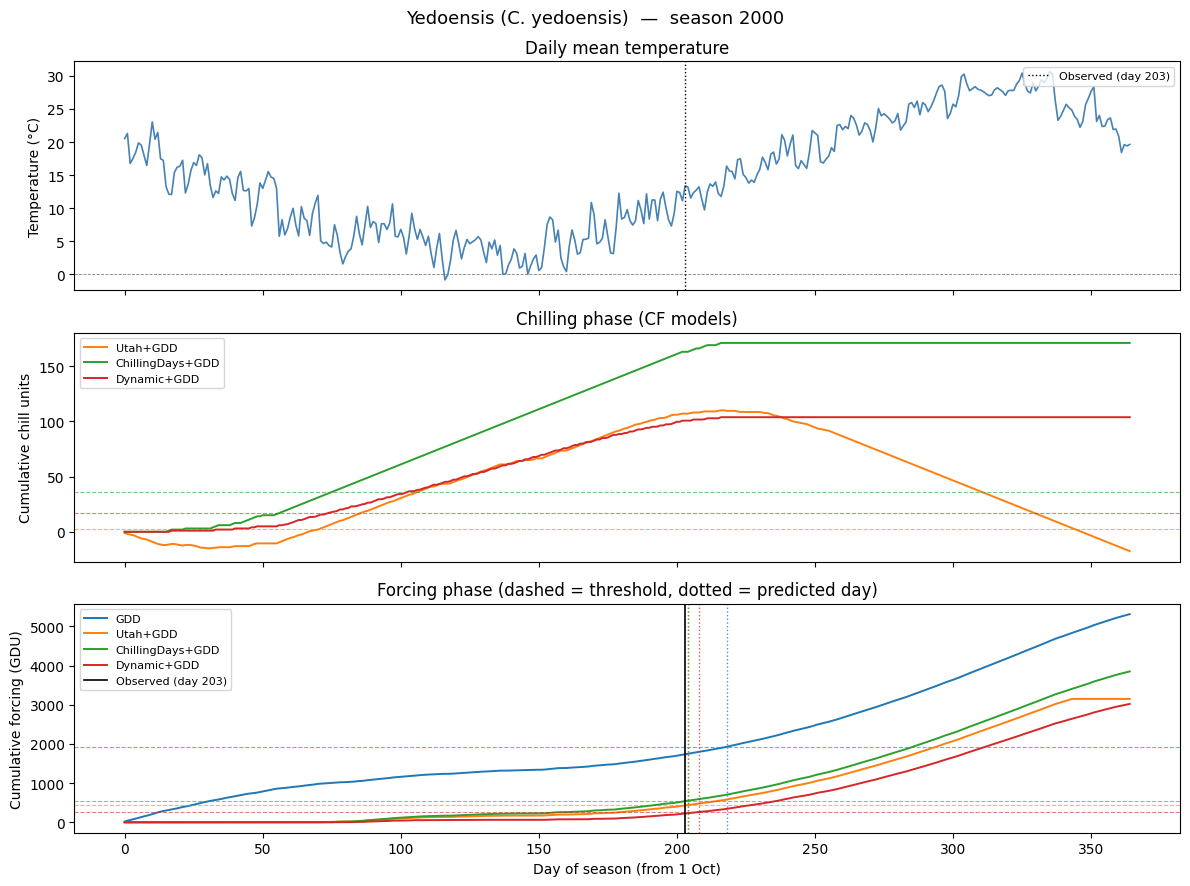

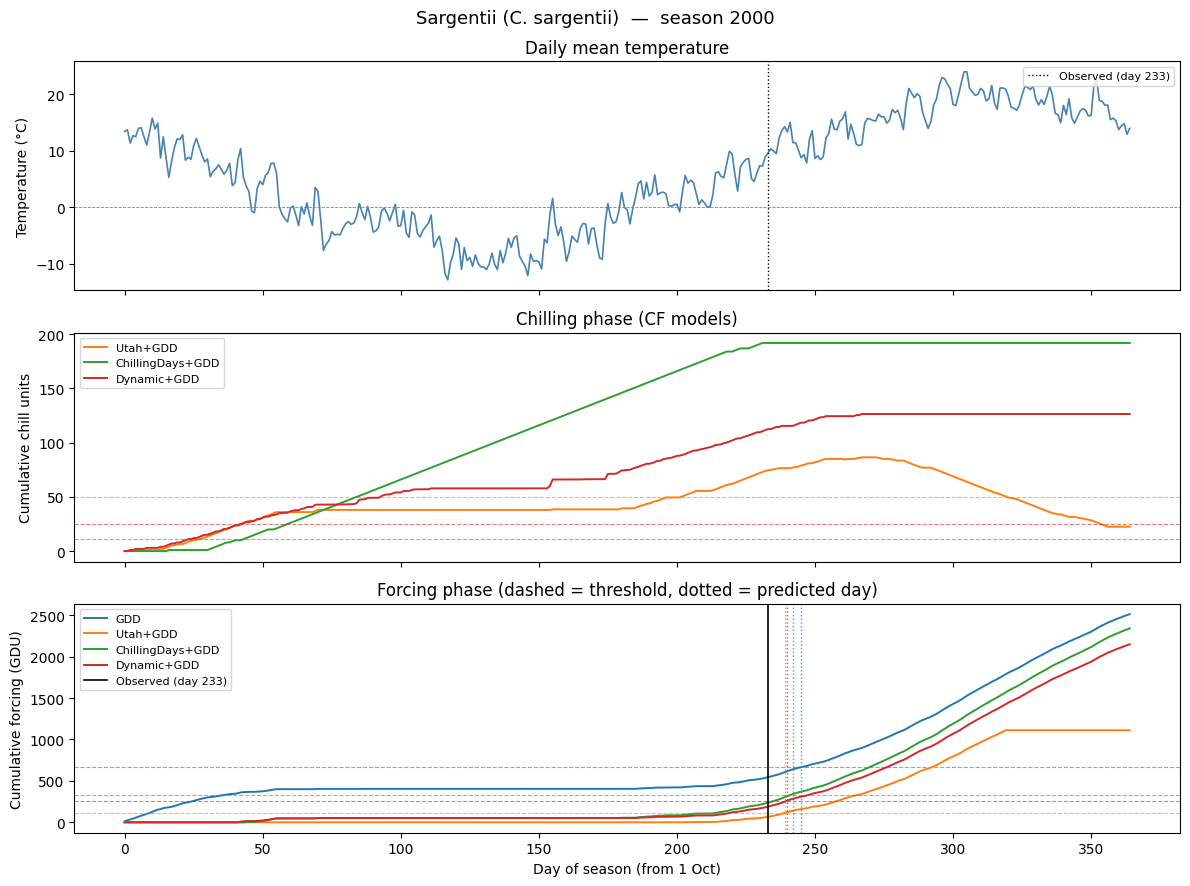

In [14]:
sample_y = pick_sample(ds_y, year=2000)
sample_s = pick_sample(ds_s, year=2000)

fig = plot_model_responses(sample_y, fitted['yedoensis'], 'Yedoensis (C. yedoensis)')
plt.show()

fig = plot_model_responses(sample_s, fitted['sargentii'], 'Sargentii (C. sargentii)')
plt.show()

### 6a. Chilling model comparison on the same temperature input

All three chilling functions applied to each sample, normalised to their
respective calibrated thresholds so the curves are directly comparable.

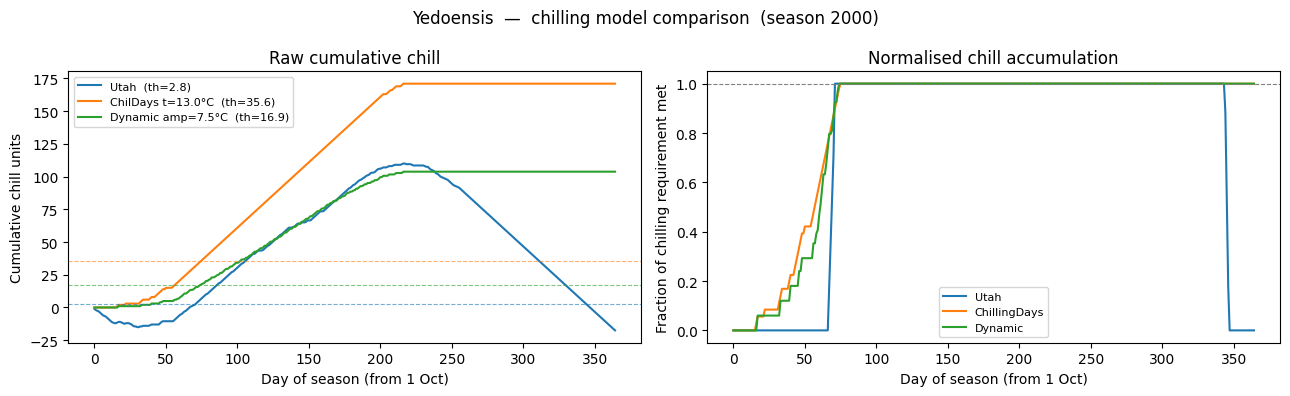

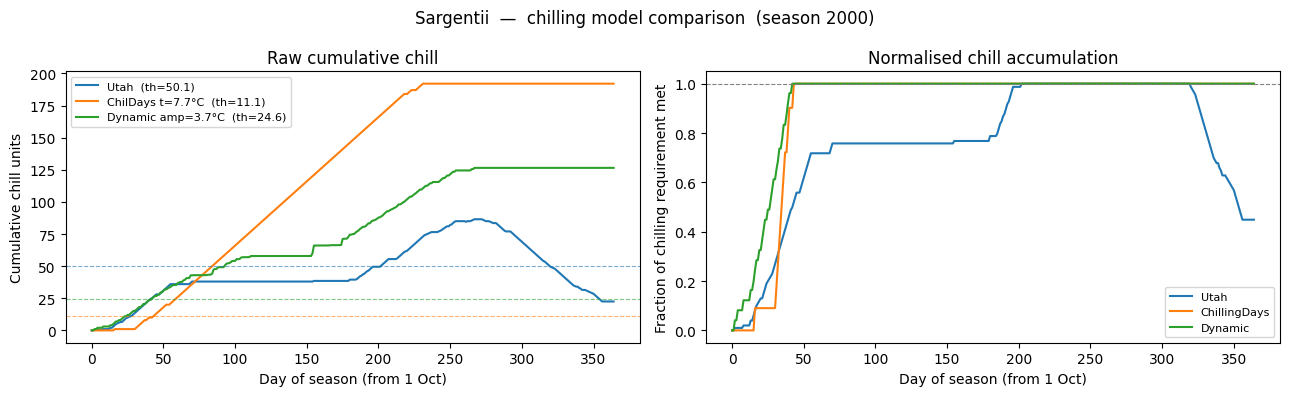

In [15]:
def plot_chill_comparison(sample, fitted_models, species_label):
    """Overlay the three chill-unit accumulation curves (raw and normalised)."""
    ts   = sample[KEY_FEATURES]['temperature_2m_mean']
    days = np.arange(len(ts))

    m_utah = fitted_models['Utah+GDD']
    m_cd   = fitted_models['ChillingDays+GDD']
    m_dyn  = fitted_models['Dynamic+GDD']

    utah_cs = np.cumsum(func_utah_chill(ts))
    cd_cs   = np.cumsum(func_chilling_days(ts, t_threshold=m_cd.t_chill))
    dyn_cs  = np.cumsum(func_dynamic_chill_daily(ts, amplitude=m_dyn.amplitude))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        f'{species_label}  —  chilling model comparison  (season {sample["year"]})',
        fontsize=12,
    )

    ax = axes[0]
    ax.plot(days, utah_cs, label=f'Utah  (th={m_utah.threshold_c:.1f})')
    ax.plot(days, cd_cs,   label=f'ChilDays t={m_cd.t_chill:.1f}°C  (th={m_cd.threshold_c:.1f})')
    ax.plot(days, dyn_cs,  label=f'Dynamic amp={m_dyn.amplitude:.1f}°C  (th={m_dyn.threshold_c:.1f})')
    ax.axhline(m_utah.threshold_c, color='C0', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(m_cd.threshold_c,   color='C1', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(m_dyn.threshold_c,  color='C2', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.set_ylabel('Cumulative chill units')
    ax.set_title('Raw cumulative chill')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(days, np.clip(utah_cs / m_utah.threshold_c, 0, 1), label='Utah')
    ax.plot(days, np.clip(cd_cs   / m_cd.threshold_c,   0, 1), label='ChillingDays')
    ax.plot(days, np.clip(dyn_cs  / m_dyn.threshold_c,  0, 1), label='Dynamic')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.set_ylabel('Fraction of chilling requirement met')
    ax.set_title('Normalised chill accumulation')
    ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


fig = plot_chill_comparison(sample_y, fitted['yedoensis'], 'Yedoensis')
plt.show()

fig = plot_chill_comparison(sample_s, fitted['sargentii'], 'Sargentii')
plt.show()

## 7. Save results

In [ ]:
# for species in ('yedoensis', 'sargentii'):
#     for name, result in results[species].items():
#         result.save()
#     for name, model in fitted[species].items():
#         model.save(f'{name.lower().replace("+", "_")}_{species}')

# print('Saved.')

PicklingError: Can't pickle local object <function zero_start.<locals>._fn at 0x74cbe766be20>